In [2]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install astropy
%pip install scipy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
import astropy
import math

In [4]:
data = pd.read_csv('M101.csv')
data.head()

mag_data = data['inst_vega_mag2'].values
diff_data = data['inst_vega_mag1'].values - mag_data
y_data = data['inst_vega_mag1'].values
x_data = -1 * diff_data

## Task 1: GLOESS Smoothed Luminosity Function

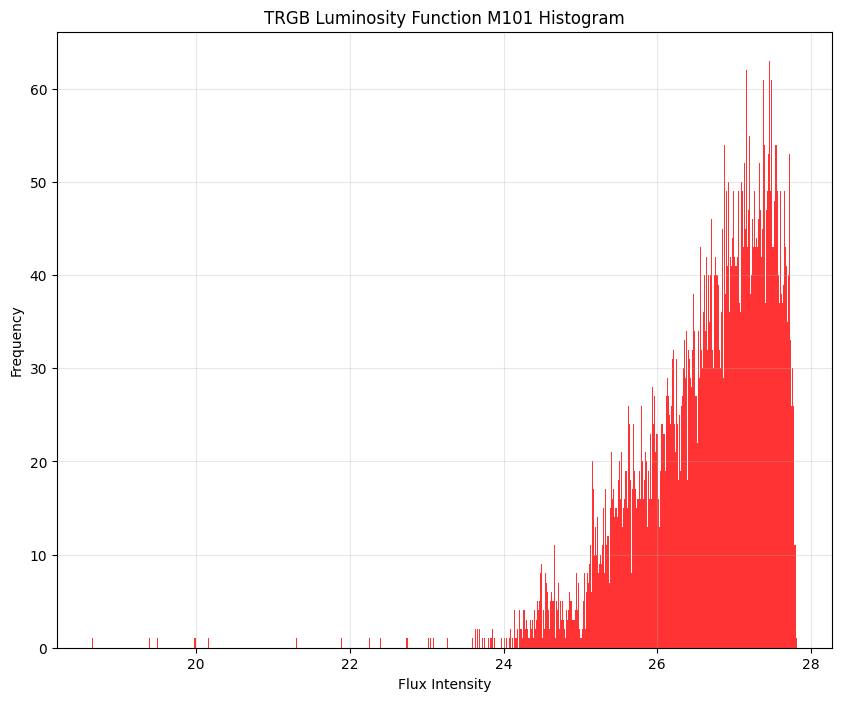

In [5]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 8))

ax_hist.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.8)
ax_hist.set_xlabel('Flux Intensity')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(True, alpha=0.3)
ax_hist.set_title('TRGB Luminosity Function M101 Histogram')

fig_hist.savefig('TRGB Luminosity Function M101 Histogram')

In [6]:
def gloess(mag, tau, bin_width = 0.01):
    fig_gloess, ax_gloess = plt.subplots(figsize = (10, 10))
    hist, bins, cont = ax_gloess.hist(mag, bins = np.arange(min(mag), max(mag) + bin_width, bin_width), color = 'black')
    plt.close()
    bin_centers = []
    for j in range(len(bins) - 1):
        bin_centers.append((bins[j] + bins[j + 1]) / 2)
    yest = np.zeros(len(hist))
    w = np.array([np.exp(- (bin_centers - bin_centers[i])**2/(2 * tau**2)) for i in range(len(hist))])
    for i in range(len(hist)):
        weights = w[i, :]
        b = np.array([np.sum(weights * hist), np.sum(weights * hist * bin_centers)])
        A = np.array([[np.sum(weights), np.sum(weights * bin_centers)],
                    [np.sum(weights * bin_centers), np.sum(weights * bin_centers * bin_centers)]])
        theta = linalg.solve(A, b)
        yest[i] = theta[0] + theta[1] * bin_centers[i]
    return yest, np.array(bin_centers)

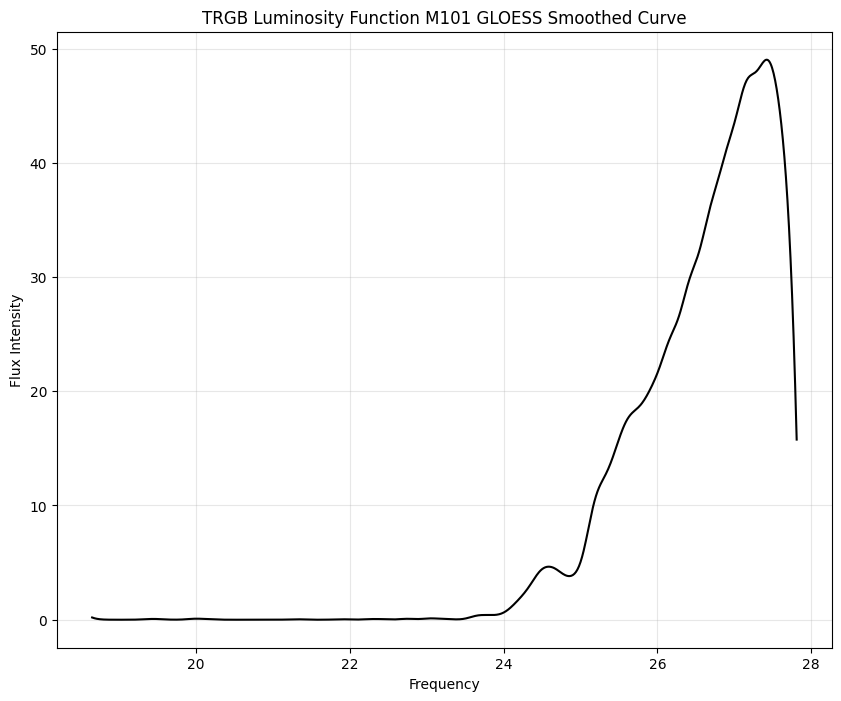

In [7]:
fig_sm, ax_sm = plt.subplots(figsize=(10, 8))

Y, X = gloess(mag_data, 0.10)
ax_sm.plot(X, Y, color='black')
ax_sm.set_ylabel('Flux Intensity')
ax_sm.set_xlabel('Frequency')
ax_sm.grid(True, alpha=0.3)
ax_sm.set_title('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

fig_sm.savefig('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

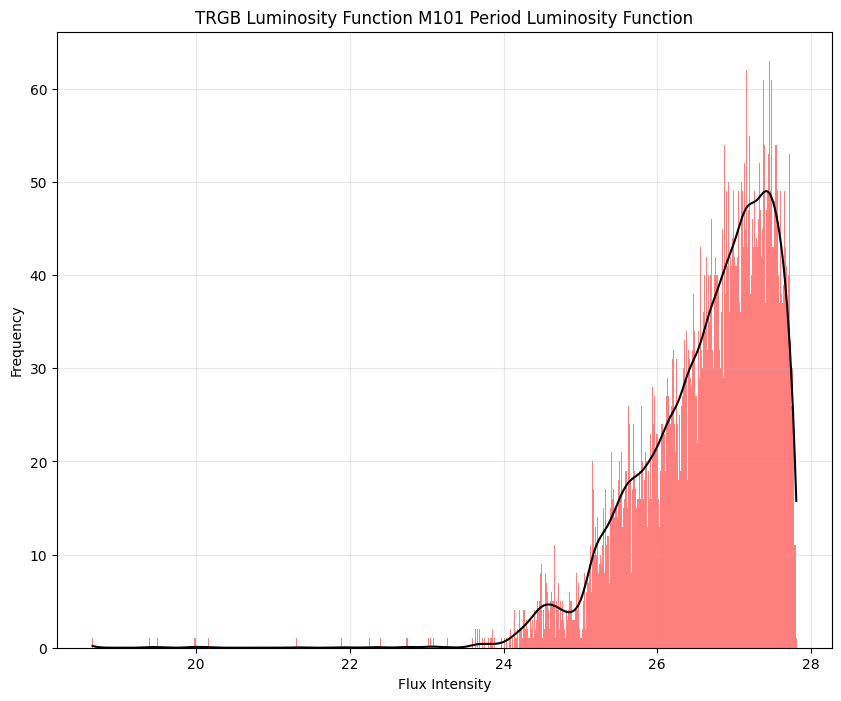

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.5)
ax.plot(X, Y, color='black')
ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
ax.set_title('TRGB Luminosity Function M101 Period Luminosity Function')

fig.savefig('TRGB Luminosity Function M101 Period Luminosity Function')

## Task 2: Sobel Response

In [9]:
def sobel_filter(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii-1] * -1 + hist[ii+1])
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def poisson_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii - 1] * -1 * 1/np.sqrt(hist[ii - 1]) + hist[ii] * 0 + hist[ii + 1] * 1* 1/np.sqrt(hist[ii + 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def hatt_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append((hist[ii + 1] - hist[ii - 1]) / np.sqrt(hist[ii + 1] + hist[ii - 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

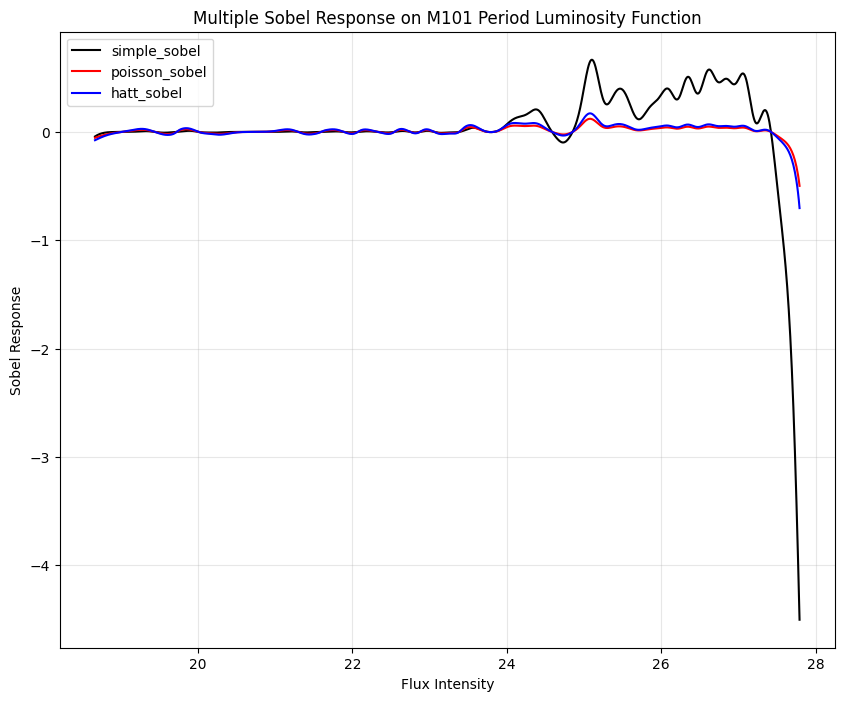

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(X[2: -2], sobel_filter(Y)[1], color='black', label='simple_sobel')
ax.plot(X[2:-2], poisson_sobel(Y)[1], color='red', label='poisson_sobel')
ax.plot(X[2:-2], hatt_sobel(Y)[1], color='blue', label='hatt_sobel')
ax.legend()

ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Sobel Response')
ax.set_title('Multiple Sobel Response on M101 Period Luminosity Function')
ax.grid(True, alpha=0.3)
fig.savefig('Multiple Sobel Response on M101 Period Luminosity Function')

## Task 3: Color Magnitude Diagrams and Assembled Plots


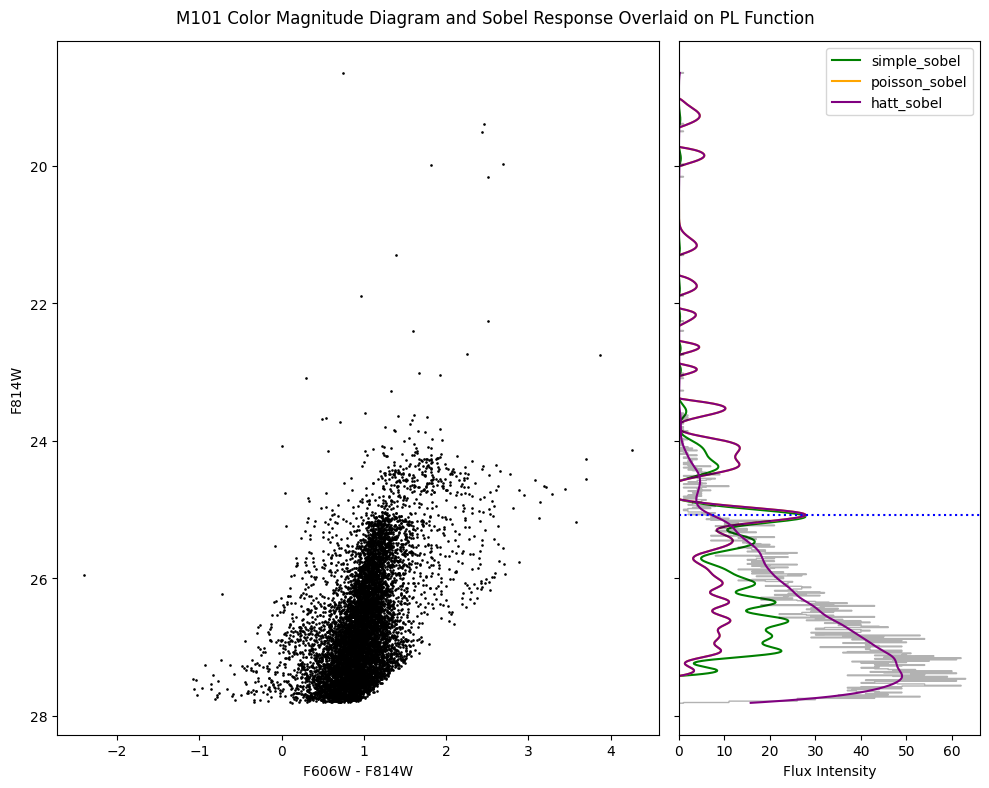

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True, gridspec_kw={'width_ratios': [2, 1]})

# CMD
ax1.scatter(diff_data, mag_data, color='black', s=0.8)
ax1.yaxis.set_inverted(True)
ax1.set_xlabel('F606W - F814W')
ax1.set_ylabel('F814W')

# sobel response
scaling_factor_hatt = np.max(mag_data) / np.max(hatt_sobel(Y)[1]) # this is for visual scaling (hatt)
scaling_factor_simple = np.max(mag_data) / np.max(sobel_filter(Y)[1]) # this is for visual scaling (simple)
scaling_factor_poisson = np.max(mag_data) / np.max(poisson_sobel(Y)[1]) # this is for visual scaling (poisson)
ax2.plot(np.maximum(scaling_factor_simple * sobel_filter(Y)[1], 0), X[2:-2], color='green', label='simple_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_poisson * poisson_sobel(Y)[1], 0), X[2:-2], color='orange', label='poisson_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_hatt * hatt_sobel(Y)[1], 0), X[2:-2], color='purple', label='hatt_sobel') # hatt sobel response > 0
ax2.yaxis.set_inverted(True)
ax2.legend()

# histogram and gloess smoothed curve
Y, X = gloess(mag_data, 0.10)
ax2.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='black', alpha=0.3, orientation='horizontal', histtype='step', label='pl_histogram')
ax2.plot(Y, X, color='purple', label='smoothed_pl_function')

# maximum sobel re
max_sobel_response = np.max(hatt_sobel(Y)[1])
max_ind = np.where(hatt_sobel(Y)[1] == max_sobel_response)
max_val = (X[2: -2])[max_ind]
ax2.axhline(y=max_val, linestyle=':', color='blue')


ax2.set_xlabel('Flux Intensity')

fig.suptitle("M101 Color Magnitude Diagram and Sobel Response Overlaid on PL Function")
fig.tight_layout()